# Terminal sets for linear MPC: polytopes, the maximal invariant set, the invariant ellipsoid, and their regions of attraction

A model predictive controller (MPC) with a short horizon needs terminal ingredients to be safe: a
terminal cost and a terminal set in which a known control law keeps the constraints forever. For a
double integrator under the LQR this notebook computes the two classic terminal sets, the maximal
positively invariant polytope and the largest invariant ellipsoid, checks each against brute force,
and then measures what the choice costs: the region of initial states from which the MPC can solve,
under a terminal equality, the ellipsoid, the polytope and no terminal set. It starts with a short
tour of the polytope tools the sets are built from.

| Scaly feature | Where |
| --- | --- |
| `si.zoh`, `mpc.lqr` | the system and its LQR |
| `mpc.Polytope`: `box`, `intersect`, `preimage`, `contains`, `support`, `is_empty`, `chebyshev_center`, `remove_redundancy`, `vertices` | the polytope tour, and every set after it |
| `mpc.max_invariant_set` | the maximal invariant set |
| `mpc.largest_ellipsoid`, `mpc.Ellipsoid` | the invariant ellipsoid |
| `mpc.OCP(terminal=...)` with `mpc.TerminalEquality`, an `Ellipsoid`, a `Polytope`; `mpc.MPC` with `"piqp"` and `"ipopt"` | the regions of attraction |
| `scaly.opt.qp.NotQuadratic` | PIQP refuses the ellipsoid |
| `ctrl.law`, `write_module` | the generated C |

This notebook needs the vendored PIQP and IPOPT (`uv sync` builds them).

In [1]:
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle, Patch
from scipy.optimize import linprog
from scipy.spatial import ConvexHull

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
from scaly import integrators as si
from scaly import mpc
from scaly.codegen import write_module
from scaly.opt.qp import NotQuadratic

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "mpc" / "terminal_sets"

## The system, its LQR and the constraint polytope

The double integrator $\ddot p = u$ with $x = (p, v)$, sampled at $\Delta t = 0.1$ s by `si.zoh`, is

$$
x_{k+1} = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix} x_k + \begin{bmatrix} \Delta t^2 / 2 \\ \Delta t \end{bmatrix} u_k ,
$$

with the limits $|p| \le 5$, $|v| \le 2$, $|u| \le 1$ and the stage cost $x^\top x + 0.1\, u^2$.
`mpc.lqr` gives the gain $K$ of the law $u = K x$ and the cost to go $x^\top P x$. The states where
both the state and the LQR's control are within their limits form the polytope

$$
\mathcal C = \mathcal X \cap \{x : |K x| \le 1\},
$$

the box intersected with the input box's preimage under $K$.

In [2]:
DT = 0.1
A, B = si.zoh(np.array([[0.0, 1.0], [0.0, 0.0]]), np.array([[0.0], [1.0]]), DT)
Q, R = np.eye(2), 0.1 * np.eye(1)
X_LO, X_HI, U_MAX = np.array([-5.0, -2.0]), np.array([5.0, 2.0]), 1.0
K, P = mpc.lqr(A, B, Q, R)
A_K = A + B @ K
X = mpc.Polytope.box(X_LO, X_HI)
KX = mpc.Polytope.box(-U_MAX, U_MAX).preimage(K)
C = X.intersect(KX)
print(f"A_d = {A.round(4).tolist()}, B_d = {B.ravel().round(4).tolist()}")
print(f"K = {np.array2string(K[0], precision=4)}; closed-loop eigenvalues {np.array2string(np.linalg.eigvals(A_K), precision=4)}")
print(f"C: {C} = the box, {X}, and |K x| <= 1, {KX}")

A_d = [[1.0, 0.1], [0.0, 1.0]], B_d = [0.005, 0.1]
K = [-2.5857 -3.4434]; closed-loop eigenvalues [0.8992 0.7436]
C: Polytope(6 rows in 2 dimensions) = the box, Polytope(4 rows in 2 dimensions), and |K x| <= 1, Polytope(2 rows in 2 dimensions)


## Polytopes in halfspace form

`mpc.Polytope(H, h)` is the set $\{x : H x \le h\}$. `box`, `intersect` and `preimage` build new
rows; `contains` tests points; every question that needs an optimization is a linear program
solved by SciPy's HiGHS:

- `support(d)` is $\max_x d^\top x$ over the set, $\infty$ when it is unbounded that way;
- `chebyshev_center()` is the centre and radius of the largest ball inside,
  $\max r$ subject to $H_i x + r \lVert H_i \rVert \le h_i$;
- `is_empty()` asks whether any point satisfies every row;
- `remove_redundancy()` drops row $i$ when $\max H_i x$ over the other rows is already at most $h_i$;
- `vertices()` intersects the halfspaces (SciPy's `HalfspaceIntersection`), for plots and areas.

Each is checked on a small set whose answer is known: the box $[-1, 1] \times [-2, 2]$, a square with
a corner cut off by $x_1 + x_2 \le 1$ and padded with three redundant rows, and the preimage of the
square under a matrix $M$, $\{x : M x \in \text{square}\}$, against mapping 2000 random points.

In [3]:
box = mpc.Polytope.box([-1.0, -2.0], [1.0, 2.0])
center, radius = box.chebyshev_center()
support_error = abs(box.support([1.0, 1.0]) - 3.0)  # max x1 + x2 on the box: 1 + 2
support_unbounded = mpc.Polytope.box([-np.inf, 0.0], [np.inf, 1.0]).support([1.0, 0.0])  # a strip, open to the right

square = mpc.Polytope.box([-1.0, -1.0], [1.0, 1.0])
cut = square.intersect(mpc.Polytope([[1.0, 1.0]], [1.0]))
padded = cut.intersect(mpc.Polytope([[1.0, -1.0], [2.0, 0.0], [0.0, 1.0]], [5.0, 2.0, 1.0]))  # a loose row, x1 <= 1 scaled, x2 <= 1 again
trimmed = padded.remove_redundancy()
vertices = trimmed.vertices()
expected = np.array([[-1.0, -1.0], [1.0, -1.0], [1.0, 0.0], [0.0, 1.0], [-1.0, 1.0]])
vertex_error = float(max(np.abs(expected - v).max(axis=1).min() for v in vertices))
area_error = abs(ConvexHull(vertices).volume - 3.5)  # the square's 4, less a corner of 1/2

M = np.array([[1.0, 0.5], [-0.3, 0.8]])
points = np.random.default_rng(0).uniform(-2.0, 2.0, (2000, 2))
preimage = square.preimage(M)
preimage_mismatches = int(np.sum(preimage.contains(points) != square.contains(points @ M.T)))
empty = (cut.is_empty(), cut.intersect(mpc.Polytope([[-1.0, 0.0]], [-2.0])).is_empty())  # x1 >= 2 misses the square

print(f"support of the box in (1, 1): 3 + {support_error:.1e}; a strip's support to the right: {support_unbounded}")
print(f"Chebyshev ball of the box: radius {radius:.6f} at ({center[0]:.1e}, {center[1]:.2f})")
print(
  f"the cut square: {padded.h.size} rows padded, {trimmed.h.size} after remove_redundancy; {len(vertices)} vertices off by {vertex_error:.1e}, area off by {area_error:.1e}"
)
print(f"preimage under M against mapping the points: {preimage_mismatches} of {len(points)} disagree; is_empty: {empty}")

support of the box in (1, 1): 3 + 0.0e+00; a strip's support to the right: inf
Chebyshev ball of the box: radius 1.000000 at (-0.0e+00, 1.00)
the cut square: 8 rows padded, 5 after remove_redundancy; 5 vertices off by 3.3e-16, area off by 4.4e-16
preimage under M against mapping the points: 0 of 2000 disagree; is_empty: (False, True)


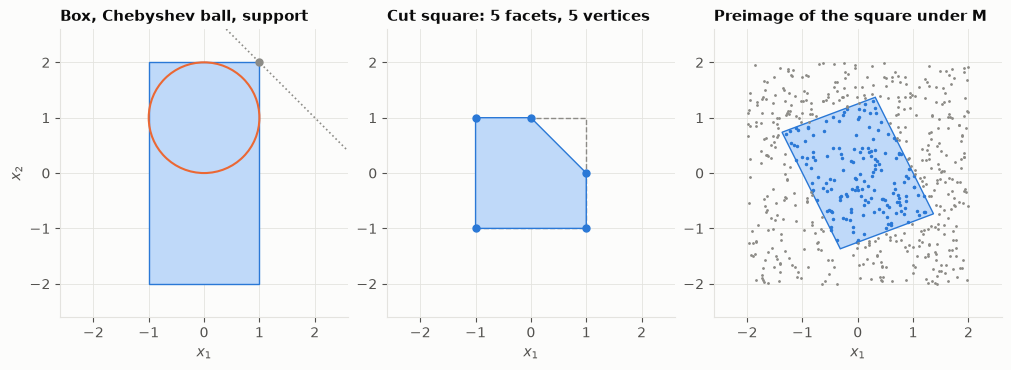

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
view = (-2.6, 2.6)
ax = axes[0]
ax.fill(*np.vstack([box.vertices(), box.vertices()[:1]]).T, fc=plotstyle.BLUES(0.2), ec=plotstyle.BLUE, lw=1)
ax.add_patch(Circle(center, radius, fill=False, ec=plotstyle.ORANGE, lw=1.5))
ax.plot([0.4, 2.6], [2.6, 0.4], ":", color=plotstyle.NEUTRAL, lw=1.2)  # x1 + x2 = 3, touching at (1, 2)
ax.plot(1, 2, "o", color=plotstyle.NEUTRAL)
ax.set_title("Box, Chebyshev ball, support")
vertices_closed = np.vstack([vertices, vertices[:1]])
ax = axes[1]
ax.fill(*np.vstack([square.vertices(), square.vertices()[:1]]).T, fill=False, ec=plotstyle.NEUTRAL, ls="--", lw=1)
ax.fill(*vertices_closed.T, fc=plotstyle.BLUES(0.2), ec=plotstyle.BLUE, lw=1)
ax.plot(*vertices.T, "o", color=plotstyle.BLUE)
ax.set_title("Cut square: 5 facets, 5 vertices")
ax = axes[2]
inside = preimage.contains(points[:600])
ax.fill(*np.vstack([preimage.vertices(), preimage.vertices()[:1]]).T, fc=plotstyle.BLUES(0.2), ec=plotstyle.BLUE, lw=1)
ax.plot(*points[:600][inside].T, ".", color=plotstyle.BLUE, ms=3)
ax.plot(*points[:600][~inside].T, ".", color=plotstyle.NEUTRAL, ms=2)
ax.set_title("Preimage of the square under M")
for ax in axes:
  ax.set_xlim(*view)
  ax.set_ylim(*view)
  ax.set_aspect("equal")
  ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
plt.show()

Every answer is exact to rounding: the support is 3, the strip's support is infinite, the Chebyshev
ball of the $2 \times 4$ box has radius 1 (its centre may sit anywhere on the segment $x_1 = 0$,
$|x_2| \le 1$; HiGHS returns one end), `remove_redundancy` keeps the 5 rows that bound the cut
square, whose vertices and area of 3.5 come out to $10^{-16}$, and the preimage agrees with mapping
the points at all 2000. Points inside the preimage (blue, right) are those that $M$ maps into the
square.

## The maximal invariant set

Under the LQR the state moves by $x^+ = A_K x$, $A_K = A_d + B_d K$. The maximal positively
invariant set in $\mathcal C = \{x : H x \le h\}$ is the set of states whose whole trajectory stays
in $\mathcal C$,

$$
\mathcal O = \{x : H A_K^t x \le h,\ t = 0, 1, 2, \dots\} .
$$

`mpc.max_invariant_set` computes it by the algorithm of E. G. Gilbert and K. T. Tan ("Linear systems
with state and control constraints: the theory and application of maximal output admissible sets",
IEEE Transactions on Automatic Control 36(9), 1991). It adds the rows of $t = 1, 2, \dots$ until
every new row is redundant given those before, one linear program per row; that proves every later
row redundant too. For a stable $A_K$ and a bounded $\mathcal C$ with the origin inside, this ends
after finitely many steps. The result has its redundant rows removed.

Three checks. Invariance: $\max_{x \in \mathcal O} (H_{\mathcal O} A_K)_i\, x \le h_{\mathcal O, i}$
for every row, so $A_K \mathcal O \subseteq \mathcal O$. Every row is a facet: without row $i$ the
set grows past $h_i$. Brute force: from each state of a $41 \times 41$ grid over $\mathcal X$ the
closed loop runs 400 steps, and the states that never leave $\mathcal C$ must be exactly those in
$\mathcal O$, away from its boundary.

In [5]:
started = time.perf_counter()
O_inf = mpc.max_invariant_set(A_K, C)
invariant_seconds = time.perf_counter() - started
invariance_excess = max(O_inf.support(row) - bound for row, bound in zip(O_inf.H @ A_K, O_inf.h, strict=True))  # <= 0
facet_gap = min(mpc.Polytope(np.delete(O_inf.H, i, axis=0), np.delete(O_inf.h, i)).support(O_inf.H[i]) - O_inf.h[i] for i in range(O_inf.h.size))

brute_grid = np.stack(np.meshgrid(np.linspace(X_LO[0], X_HI[0], 41), np.linspace(X_LO[1], X_HI[1], 41)), axis=-1).reshape(-1, 2)
safe, states = np.ones(len(brute_grid), dtype=bool), brute_grid.copy()
for _ in range(400):
  safe &= C.contains(states)
  states = states @ A_K.T
margin = np.min(O_inf.h[None, :] - brute_grid @ O_inf.H.T, axis=1)
away = np.abs(margin) > 1e-6  # a grid point on the boundary may go either way
brute_mismatches = int(np.sum(np.asarray(O_inf.contains(brute_grid))[away] != safe[away]))
print(f"{O_inf}: {O_inf.h.size} facets, in {invariant_seconds:.3f} s")
print(f"invariance: largest support excess {invariance_excess:.1e}; every row a facet: smallest gap {facet_gap:.2e}")
print(
  f"brute force: {safe.sum()} of {len(brute_grid)} grid states never leave C; {brute_mismatches} disagree with the set, {np.sum(~away)} on its boundary skipped"
)

Polytope(16 rows in 2 dimensions): 16 facets, in 0.066 s
invariance: largest support excess 8.9e-16; every row a facet: smallest gap 1.10e-02
brute force: 101 of 1681 grid states never leave C; 0 disagree with the set, 0 on its boundary skipped


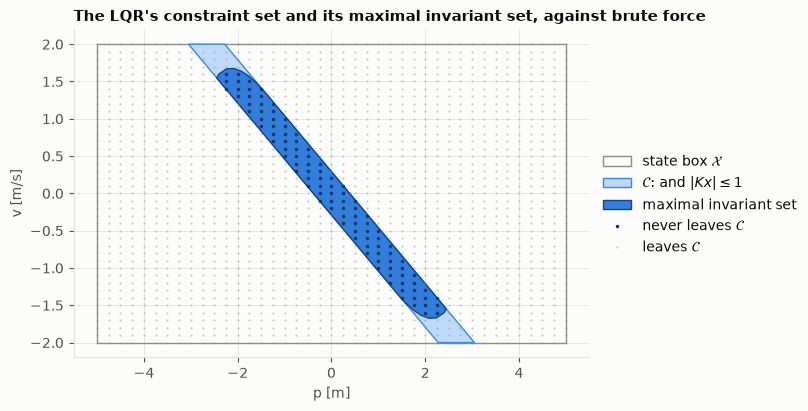

In [6]:
def fill(ax, polytope, **style):
  corners = polytope.vertices()
  return ax.fill(*np.vstack([corners, corners[:1]]).T, **style)


fig, ax = plt.subplots(figsize=(8, 4))
fill(ax, X, fill=False, ec=plotstyle.NEUTRAL, lw=1, label="state box $\\mathcal{X}$")
fill(ax, C, fc=plotstyle.BLUES(0.2), ec=plotstyle.BLUES(0.5), lw=1, label="$\\mathcal{C}$: and $|Kx| \\leq 1$")
fill(ax, O_inf, fc=plotstyle.BLUES(0.55), ec=plotstyle.BLUES(0.9), lw=1, label="maximal invariant set")
ax.plot(*brute_grid[safe].T, ".", color=plotstyle.BLUES(1.0), ms=3, label="never leaves $\\mathcal{C}$")
ax.plot(*brute_grid[~safe].T, ".", color=plotstyle.NEUTRAL, ms=1, alpha=0.5, label="leaves $\\mathcal{C}$")
ax.set_xlabel("p [m]")
ax.set_ylabel("v [m/s]")
ax.set_title("The LQR's constraint set and its maximal invariant set, against brute force")
fig.legend(loc="outside right center")
plt.show()

The set has 16 facets and takes 0.04 s. Its image under $A_K$ stays inside it to $10^{-15}$, and
every row is a facet by a margin of at least 0.011. Of the 1681 grid states, 101 never leave
$\mathcal C$ in 400 steps, and they are exactly the grid states inside the set: none disagrees, and
no grid state lies within $10^{-6}$ of its boundary. The input band $|K x| \le 1$, with
$K x = -2.59\, p - 3.44\, v$, is what shapes $\mathcal C$: at rest the LQR asks for more than the unit
force once $p$ is 0.39 m out, so $\mathcal C$ is a thin diagonal band and the position limits of
$\pm 5$ m never bind in it. The speed limits cut the band's ends, and invariance rounds those ends
off, removing the states whose LQR trajectory would later leave $\mathcal C$.

## The largest invariant ellipsoid

The cost to go $V(x) = x^\top P x$ falls along the LQR closed loop,
$V(A_K x) = V(x) - x^\top (Q + K^\top R K) x$, so every level set $\{x : x^\top P x \le \alpha\}$ is
invariant. The largest one inside $\mathcal C$ touches its tightest row:

$$
\alpha = \min_i \frac{h_i^2}{H_i P^{-1} H_i^\top} .
$$

`mpc.largest_ellipsoid(P, C)` returns it as an `mpc.Ellipsoid`. Since it is invariant and inside
$\mathcal C$, it lies in the maximal invariant set. The checks sample 2000 points in the ellipsoid, a
quarter of them on its boundary, map them by $A_K$, and compare areas: the ellipse's is
$\pi \alpha / \sqrt{\det P}$, the polytopes' come from their vertices.

In [7]:
E = mpc.largest_ellipsoid(P, C)
rng = np.random.default_rng(1)
angles = rng.uniform(0.0, 2 * np.pi, 2000)
radii = np.sqrt(rng.uniform(size=2000))
radii[::4] = 1.0
unit = np.stack([np.cos(angles), np.sin(angles)], axis=-1) * radii[:, None]
samples = np.sqrt(E.alpha) * np.linalg.solve(np.linalg.cholesky(E.P).T, unit.T).T  # x'Px = alpha |z|^2
images = samples @ A_K.T
image_level = float(np.max(np.einsum("ni,ij,nj->n", images, E.P, images)) / E.alpha)
touch = float(np.max(np.sqrt(E.alpha * np.einsum("ij,jk,ik->i", C.H, np.linalg.inv(E.P), C.H)) / C.h))
samples_outside = len(samples) - int(np.sum(E.contains(samples, tol=1e-12)))
outside_constraints = len(samples) - int(np.sum(C.contains(samples)))
outside_invariant = len(samples) - int(np.sum(O_inf.contains(samples)))
area_ellipsoid = float(np.pi * E.alpha / np.sqrt(np.linalg.det(E.P)))
area_invariant, area_constraints = ConvexHull(O_inf.vertices()).volume, ConvexHull(C.vertices()).volume
print(f"alpha = {E.alpha:.6f}; the ellipsoid touches C at {touch:.12f} of its tightest row")
print(
  f"samples: {samples_outside} outside E, {outside_constraints} outside C, {outside_invariant} outside the invariant set; images reach {image_level:.4f} alpha"
)
print(
  f"areas: ellipsoid {area_ellipsoid:.4f}, invariant set {area_invariant:.4f}, C {area_constraints:.4f}; the ellipsoid covers {area_ellipsoid / area_invariant:.1%} of the invariant set"
)

alpha = 0.387750; the ellipsoid touches C at 1.000000000000 of its tightest row
samples: 0 outside E, 0 outside C, 0 outside the invariant set; images reach 0.8873 alpha
areas: ellipsoid 0.1705, invariant set 2.5120, C 3.0939; the ellipsoid covers 6.8% of the invariant set


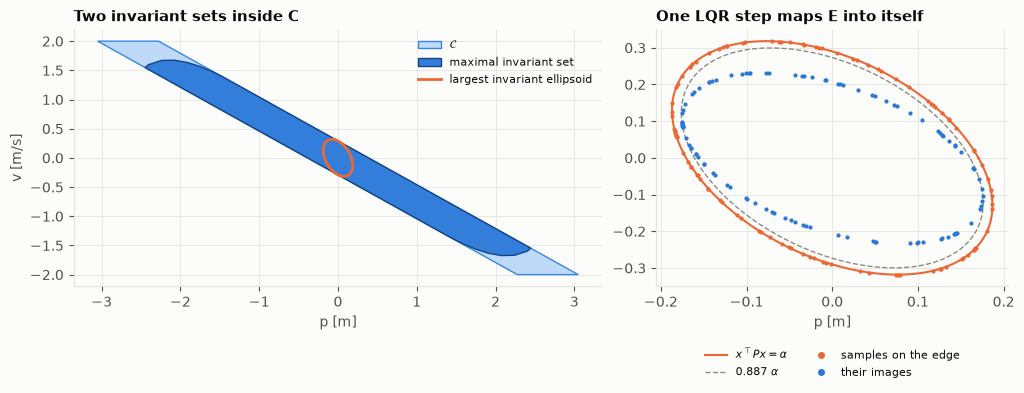

In [8]:
def ellipse(ax, level, **style):
  circle = np.stack([np.cos(np.linspace(0, 2 * np.pi, 200)), np.sin(np.linspace(0, 2 * np.pi, 200))], axis=-1)
  return ax.plot(*(np.sqrt(level) * np.linalg.solve(np.linalg.cholesky(E.P).T, circle.T)), **style)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [1.5, 1]})
fill(ax1, C, fc=plotstyle.BLUES(0.2), ec=plotstyle.BLUES(0.5), lw=1, label="$\\mathcal{C}$")
fill(ax1, O_inf, fc=plotstyle.BLUES(0.55), ec=plotstyle.BLUES(0.9), lw=1, label="maximal invariant set")
ellipse(ax1, E.alpha, color=plotstyle.ORANGE, lw=2, label="largest invariant ellipsoid")
ax1.set_xlabel("p [m]")
ax1.set_ylabel("v [m/s]")
ax1.set_title("Two invariant sets inside C")
ax1.legend(loc="upper right", fontsize=8)
on_edge = radii == 1.0
ellipse(ax2, E.alpha, color=plotstyle.ORANGE, lw=1.5, label="$x^\\top P x = \\alpha$")
ellipse(ax2, image_level * E.alpha, color=plotstyle.NEUTRAL, lw=1, ls="--", label=f"{image_level:.3f} $\\alpha$")
ax2.plot(*samples[on_edge][::5].T, ".", color=plotstyle.ORANGE, ms=4, label="samples on the edge")
ax2.plot(*images[on_edge][::5].T, ".", color=plotstyle.BLUE, ms=4, label="their images")
ax2.set_xlabel("p [m]")
ax2.set_title("One LQR step maps E into itself")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=8, markerscale=2)
plt.show()

The ellipsoid's level is $\alpha = 0.3878$, and it touches $\mathcal C$ exactly (the ratio is 1 to
twelve digits). No sample leaves $\mathcal C$ or the maximal invariant set, and one LQR step brings
even the boundary samples in to $0.887\,\alpha$. But the ellipsoid is small: its area is 0.170,
6.8 % of the invariant polytope's 2.512, itself 81 % of $\mathcal C$'s 3.094. A level set of the
cost is an ellipse tilted differently from $\mathcal C$, a long thin diagonal band: it touches the
band's sides near the origin and covers little of its length.

## Regions of attraction

The same MPC, horizon $N = 20$, with the LQR cost as terminal cost,

$$
\min_{x, u}\ \sum_{k=0}^{N-1} \left( x_k^\top Q x_k + u_k^\top R u_k \right) + x_N^\top P x_N
\quad \text{s.t.} \quad x_0 = \hat x,\ \ x_{k+1} = A_d x_k + B_d u_k,\ \ |u_k| \le 1,\ \ x_k \in \mathcal X\ (k \ge 1),\ \ x_N \in \mathcal T ,
$$

is solved from every state of a $21 \times 17$ grid over $\mathcal X$ with four terminal sets
$\mathcal T$: the origin (`mpc.TerminalEquality()`), the ellipsoid, the maximal invariant set, and
none. The states from which it can solve are its region of attraction, the states that $N$ steps can
steer into $\mathcal T$. Since $\{0\} \subset E \subset \mathcal O \subset \mathbb R^2$, the regions
nest in the same order. The ellipsoid's row $x_N^\top P x_N \le \alpha$ is quadratic, which makes
that problem a nonlinear program for IPOPT; the other three are QPs for PIQP. One controller per
terminal set serves the whole grid, each solve from `ctrl.initial_guess(x)`.

The verdicts are checked two ways. For the three polyhedral sets, feasibility is a linear program in
the controls, with $x_k = A_d^k \hat x + \sum_{j<k} A_d^{k-1-j} B_d u_j$, solved by SciPy's HiGHS.
For the ellipsoid, $E$ is reachable exactly when the smallest reachable $x_N^\top P x_N$ is at most
$\alpha$, a QP (terminal cost only, no terminal set) for PIQP.

In [9]:
HORIZON = 20
grid = np.stack(np.meshgrid(np.linspace(X_LO[0], X_HI[0], 21), np.linspace(X_LO[1], X_HI[1], 17)), axis=-1).reshape(-1, 2)
step = mpc.linear(A, B, name="tsets_step")
PIQP, IPOPT = {"eps_abs": 1e-9, "eps_rel": 1e-9}, {"tol": 1e-9}


def ocp(terminal, tag, stage=True):
  return mpc.OCP(
    step=step,
    horizon=HORIZON,
    stage_cost=mpc.Quadratic(Q, R) if stage else None,
    terminal_cost=mpc.Quadratic(P),
    u_bounds=(-U_MAX, U_MAX),
    x_bounds=(X_LO, X_HI),
    terminal=terminal,
    name=f"tsets_{tag}",
  )


choices = {
  "equality": (mpc.TerminalEquality(), "piqp", PIQP),
  "ellipsoid": (E, "ipopt", IPOPT),
  "polytope": (O_inf, "piqp", PIQP),
  "none": (None, "piqp", PIQP),
}
controllers, ok, statuses, seconds, ellipsoid_end_level = {}, {}, {}, {}, 0.0
for name, (terminal, solver, options) in choices.items():
  ctrl = mpc.MPC(ocp(terminal, name), solver, options=options)
  started, verdicts, names = time.perf_counter(), [], []
  for x in grid:
    solution = ctrl.solve(x, guess=ctrl.initial_guess(x))
    verdicts.append(solution.status.ok)
    names.append(solution.status.name)
    if name == "ellipsoid" and solution.status.ok:
      ellipsoid_end_level = max(ellipsoid_end_level, float(solution.xs[-1] @ E.P @ solution.xs[-1] / E.alpha))
  controllers[name], ok[name], seconds[name], statuses[name] = ctrl, np.array(verdicts), time.perf_counter() - started, dict(Counter(names))
fraction = {name: float(ok[name].mean()) for name in choices}
print(f"{'terminal set':<12} {'solver':<6} {'feasible':>8} {'time s':>7}  statuses")
for name, (_, solver, _) in choices.items():
  print(f"{name:<12} {solver:<6} {fraction[name]:>8.1%} {seconds[name]:>7.2f}  {statuses[name]}")

terminal set solver feasible  time s  statuses
equality     piqp      11.5%    0.64  {'MAX_ITER': 316, 'OK': 41}
ellipsoid    ipopt     20.4%    4.40  {'PRIMAL_INFEASIBLE': 284, 'OK': 73}
polytope     piqp      62.5%    0.45  {'MAX_ITER': 134, 'OK': 223}
none         piqp      90.5%    0.30  {'MAX_ITER': 34, 'OK': 323}


In [10]:
phi = np.vstack([np.linalg.matrix_power(A, k) for k in range(1, HORIZON + 1)])  # (x_1 .. x_N) = phi x_0 + gamma u
gamma = np.zeros((2 * HORIZON, HORIZON))
for k in range(HORIZON):
  for j in range(k + 1):
    gamma[2 * k : 2 * k + 2, j] = (np.linalg.matrix_power(A, k - j) @ B)[:, 0]


def lp_feasible(x0, terminal):
  free = phi @ x0
  a_ub, b_ub = np.vstack([gamma, -gamma]), np.concatenate([np.tile(X_HI, HORIZON) - free, free - np.tile(X_LO, HORIZON)])
  a_eq = b_eq = None
  if terminal == "polytope":
    a_ub, b_ub = np.vstack([a_ub, O_inf.H @ gamma[-2:]]), np.concatenate([b_ub, O_inf.h - O_inf.H @ free[-2:]])
  elif terminal == "equality":
    a_eq, b_eq = gamma[-2:], -free[-2:]
  return linprog(np.zeros(HORIZON), A_ub=a_ub, b_ub=b_ub, A_eq=a_eq, b_eq=b_eq, bounds=[(-U_MAX, U_MAX)] * HORIZON, method="highs").status == 0


lp = {name: np.array([lp_feasible(x, name) for x in grid]) for name in ("equality", "polytope", "none")}
lp_mismatches = {name: int(np.sum(ok[name] != lp[name])) for name in lp}

nearest = mpc.MPC(ocp(None, "nearest", stage=False), "piqp", options=PIQP)
level = np.full(len(grid), np.inf)
for i, x in enumerate(grid):
  if lp["none"][i]:
    level[i] = nearest.solve(x, guess=nearest.initial_guess(x)).cost / E.alpha
clear = np.abs(level - 1.0) > 1e-6  # a state whose nearest x_N sits on E's boundary may go either way
ellipsoid_qp_mismatches = int(np.sum((ok["ellipsoid"] != (level <= 1.0))[clear]))

order = list(choices)
nesting_violations = {f"{inner} in {outer}": int(np.sum(ok[inner] & ~ok[outer])) for inner, outer in zip(order, order[1:])}
print(f"against HiGHS feasibility LPs: {lp_mismatches}")
print(f"IPOPT against min x_N'Px_N <= alpha by PIQP: {ellipsoid_qp_mismatches} mismatches, {np.sum(~clear)} on the boundary skipped")
print(f"the largest x_N'Px_N / alpha IPOPT returned: {ellipsoid_end_level:.9f}")
print(f"nesting violations: {nesting_violations}")

against HiGHS feasibility LPs: {'equality': 0, 'polytope': 0, 'none': 0}
IPOPT against min x_N'Px_N <= alpha by PIQP: 0 mismatches, 0 on the boundary skipped
the largest x_N'Px_N / alpha IPOPT returned: 1.000000026
nesting violations: {'equality in ellipsoid': 0, 'ellipsoid in polytope': 0, 'polytope in none': 0}


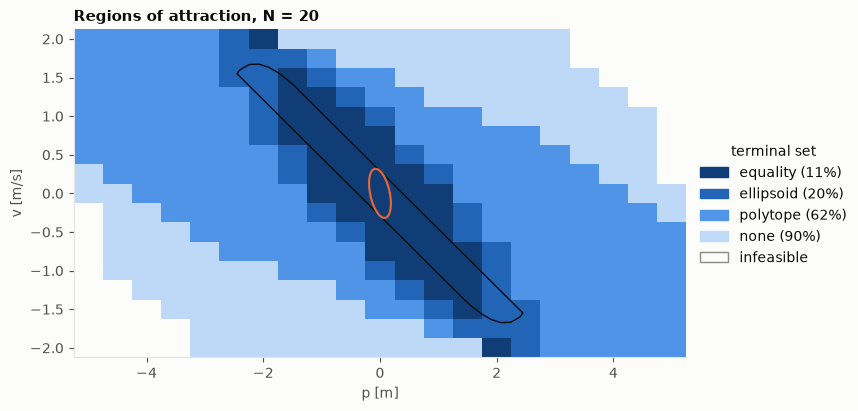

In [11]:
depth = sum(ok[name].astype(int) for name in order).reshape(17, 21)  # 4: every terminal set, 1: none only
shades = [plotstyle.SURFACE, plotstyle.BLUES(0.2), plotstyle.BLUES(0.45), plotstyle.BLUES(0.7), plotstyle.BLUES(0.95)]
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.imshow(
  depth,
  origin="lower",
  extent=(X_LO[0] - 0.25, X_HI[0] + 0.25, X_LO[1] - 0.125, X_HI[1] + 0.125),
  aspect="auto",
  cmap=ListedColormap(shades),
  vmin=-0.5,
  vmax=4.5,
  interpolation="nearest",
)
fill(ax, O_inf, fill=False, ec=plotstyle.TEXT, lw=1)
ellipse(ax, E.alpha, color=plotstyle.ORANGE, lw=1.5)
ax.grid(False)
ax.set_xlabel("p [m]")
ax.set_ylabel("v [m/s]")
ax.set_title(f"Regions of attraction, N = {HORIZON}")
handles = [Patch(color=shades[4 - i], label=f"{name} ({fraction[name]:.0%})") for i, name in enumerate(order)]
handles.append(Patch(fc=shades[0], ec=plotstyle.NEUTRAL, label="infeasible"))
fig.legend(handles=handles, loc="outside right center", title="terminal set")
plt.show()

The regions nest as they must, with no grid state out of order, and the terminal set makes a large
difference at this horizon. From 11.5 % of the grid the MPC can reach the origin exactly in 20
steps, from 20.4 % the ellipsoid, from 62.5 % the maximal invariant set, and from 90.5 % it can
merely keep the state in its box; in the two corners left out the state moves towards a position
limit too fast to stop before it. The
picture shows each region as the set of states $N = 20$ steps can steer into the terminal set drawn
at the centre: the invariant polytope (black outline) and the ellipsoid (orange). Every PIQP verdict
agrees with HiGHS, and every IPOPT verdict with the nearest-reachable QP; the largest terminal level
IPOPT accepted is $1 + 2.6 \times 10^{-8}$ times $\alpha$, within its constraint tolerance.

The statuses show a difference between the solvers: IPOPT reports the 284 infeasible problems as
`PRIMAL_INFEASIBLE`, while PIQP runs to its limit of 250 iterations on every infeasible QP of this
form and reports `MAX_ITER`. Neither counts as a success, so the regions are right, but each
infeasible point costs PIQP its full 250 iterations, which is why the equality row, infeasible on
most of the grid, takes the longest of the three QPs.

## PIQP refuses the ellipsoid

A QP solver takes linear constraints only. When `mpc.MPC` builds the solver, Scaly proves the
problem's structure from its graph: the cost quadratic and every constraint affine in the variables.
The ellipsoid's row $x_N^\top P x_N \le \alpha$ is not, and the proof names it.

In [12]:
try:
  mpc.MPC(controllers["ellipsoid"].ocp, "piqp")
  refused = ""
except NotQuadratic as error:
  refused = str(error)
print(f"NotQuadratic: {refused}")

NotQuadratic: tsets_ellipsoid: ineq terminal_ellipsoid is not affine in the variables


## Checks

In [13]:
assert support_error < 1e-9 and support_unbounded == np.inf and abs(radius - 1) < 1e-9
assert (padded.h.size, trimmed.h.size) == (8, 5) and len(vertices) == 5 and vertex_error < 1e-9 and area_error < 1e-9
assert preimage_mismatches == 0 and empty == (False, True)
assert O_inf.h.size == 16 and invariance_excess < 1e-9 and facet_gap > 1e-3
assert brute_mismatches == 0 and safe.sum() > 50  # exactly the states whose closed loop stays inside
assert abs(touch - 1) < 1e-9 and image_level < 1
assert samples_outside == outside_constraints == outside_invariant == 0
assert area_ellipsoid < area_invariant < area_constraints
assert 0 < fraction["equality"] < fraction["ellipsoid"] < fraction["polytope"] < fraction["none"] < 1
assert not any(nesting_violations.values()) and not any(lp_mismatches.values())
assert ellipsoid_qp_mismatches == 0 and ellipsoid_end_level < 1 + 1e-6
assert "terminal_ellipsoid" in refused
print("all 12 checks passed")

all 12 checks passed


## The generated C

The polytope-terminal controller's `law` is one Function, `law(x0, guess) -> (u, guess_next)`:
PIQP nested, the QP's data and the terminal set's 16 rows evaluated in generated code, and the warm
start shifted in the same code.

In [14]:
law = controllers["polytope"].law
module = write_module(law, GENERATED)
print(
  f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB; guess_size = {controllers['polytope'].guess_size}"
)
print("\n".join(line for line in module.header.splitlines() if line.startswith(("int ", "static inline int"))))

tsets_polytope_law.c: 540 lines, 27 kB; guess_size = 182
int tsets_polytope_law(const double** arg, double** res, int* iw, double* w, int mem);
int tsets_polytope_piqp_stats(scaly_solver_stats* out);
static inline int tsets_polytope_law_call(const tsets_polytope_law_x0_t* x0, const tsets_polytope_law_guess_t* guess, tsets_polytope_law_u_t* u, tsets_polytope_law_guess_next_t* guess_next, tsets_polytope_law_workspace_t* workspace) {


The source links against the vendored PIQP; the files are in `examples/generated/mpc/terminal_sets/`.